In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math
import numpy as np
import joblib
import os
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from statsmodels.stats.outliers_influence import variance_inflation_factor

import mlflow


# 1. Contexte et EDA

On commence par visualiser notre dataset pour bien comprendre nos données et son contexte.

## 1.1. Exploration préliminaire

In [3]:
df = pd.read_csv('data/Loan_Data.csv')

In [4]:
df.head()

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               10000 non-null  int64  
 1   credit_lines_outstanding  10000 non-null  int64  
 2   loan_amt_outstanding      10000 non-null  float64
 3   total_debt_outstanding    10000 non-null  float64
 4   income                    10000 non-null  float64
 5   years_employed            10000 non-null  int64  
 6   fico_score                10000 non-null  int64  
 7   default                   10000 non-null  int64  
dtypes: float64(3), int64(5)
memory usage: 625.1 KB


In [6]:
# Valeurs nulles
df.isnull().sum()

customer_id                 0
credit_lines_outstanding    0
loan_amt_outstanding        0
total_debt_outstanding      0
income                      0
years_employed              0
fico_score                  0
default                     0
dtype: int64

In [7]:
# Doublons 
len_df1 = len(df)

df.drop_duplicates(inplace=True)
len_df2 = len(df)

print(f"Nombre de lignes en double : {len_df1 - len_df2}")

Nombre de lignes en double : 0


**ANALYSE :**

Cette analyse préliminaire nous montre que :
- toutes les colonnes ont le même nombre de lignes ; 
- leurs données sont toutes de types numériques (int64 ou float64) ; 
- la df ne contient pas de valeur nulle ;
- la df ne contient pas de ligne dédoublée.

Ces résultats sont cohérents avec l'idée d'un dataset destiné à l'exercice.

In [8]:
df.describe()

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.974577e+06,1.461200,4159.677034,8718.916797,70039.901401,4.552800,637.557700,0.185100
std,2.293890e+06,1.743846,1421.399078,6627.164762,20072.214143,1.566862,60.657906,0.388398
min,1.000324e+06,0.000000,46.783973,31.652732,1000.000000,0.000000,408.000000,0.000000
25%,2.977661e+06,0.000000,3154.235371,4199.836020,56539.867903,3.000000,597.000000,0.000000
50%,4.989502e+06,1.000000,4052.377228,6732.407217,70085.826330,5.000000,638.000000,0.000000
75%,6.967210e+06,2.000000,5052.898103,11272.263740,83429.166133,6.000000,679.000000,0.000000
max,8.999789e+06,5.000000,10750.677810,43688.784100,148412.180500,10.000000,850.000000,1.000000


**ANALYSE :**

*Significations des colonnes :*

Les titres des 8 colonnes de la df sont des éléments cruciaux pour comprendre le contexte de notre projet. Si certaines colonnes sont complètement transparentes (customer_id), d'autres sont moins  claires (fico_score), et méritent d'être définies. Cela nous permettra d'éviter d'éventuelles situation de colinéarité. 

1) 'customer_id' : information classique, elle attribue à chaque client un identifiant unique, de valeur numérique d'après l'exploration précédente. Le numéro étant en général attribué aléatoirement, cette valeur n'est en théorie pas corrélée à la solvabilité du client. Il conviendra donc de la retirer du dataset lors de l'entraînement des modèles de regression.

2) 'credit_lines_outstanding' : il s'agit du nombre de crédits que le client a en cours (entre 0 et 2 par client dans notre jeu de données) ;

3) 'loan_amt_outstanding' : montant qu'il reste à rembourser pour le prêt contracté étudié  ;

4) 'total_debt_outstanding' : niveau de dette total du client ;

5) 'income' : revenu du client ;

6) 'years_employed': ancienneté dans l'emploi actuel ;

7) 'fico_score': note de confiance attribuée aux clients par les banques américaines. Il est généralement calculé sur 5 piliers : l'hitorique de paiements, le taux d'utilisation de la carte de crédit, l'ancienneté du client, la diversité du panier de crédits, et l'ouverture récente de nouveaux crédits. Il va généralement de 300 (mauvais) à 850 (bon) ;

6) 'default': colonne de prédiction : indique si le client fait défaut ou non sur son prêt (1 = défaut, 0 = client solvable).

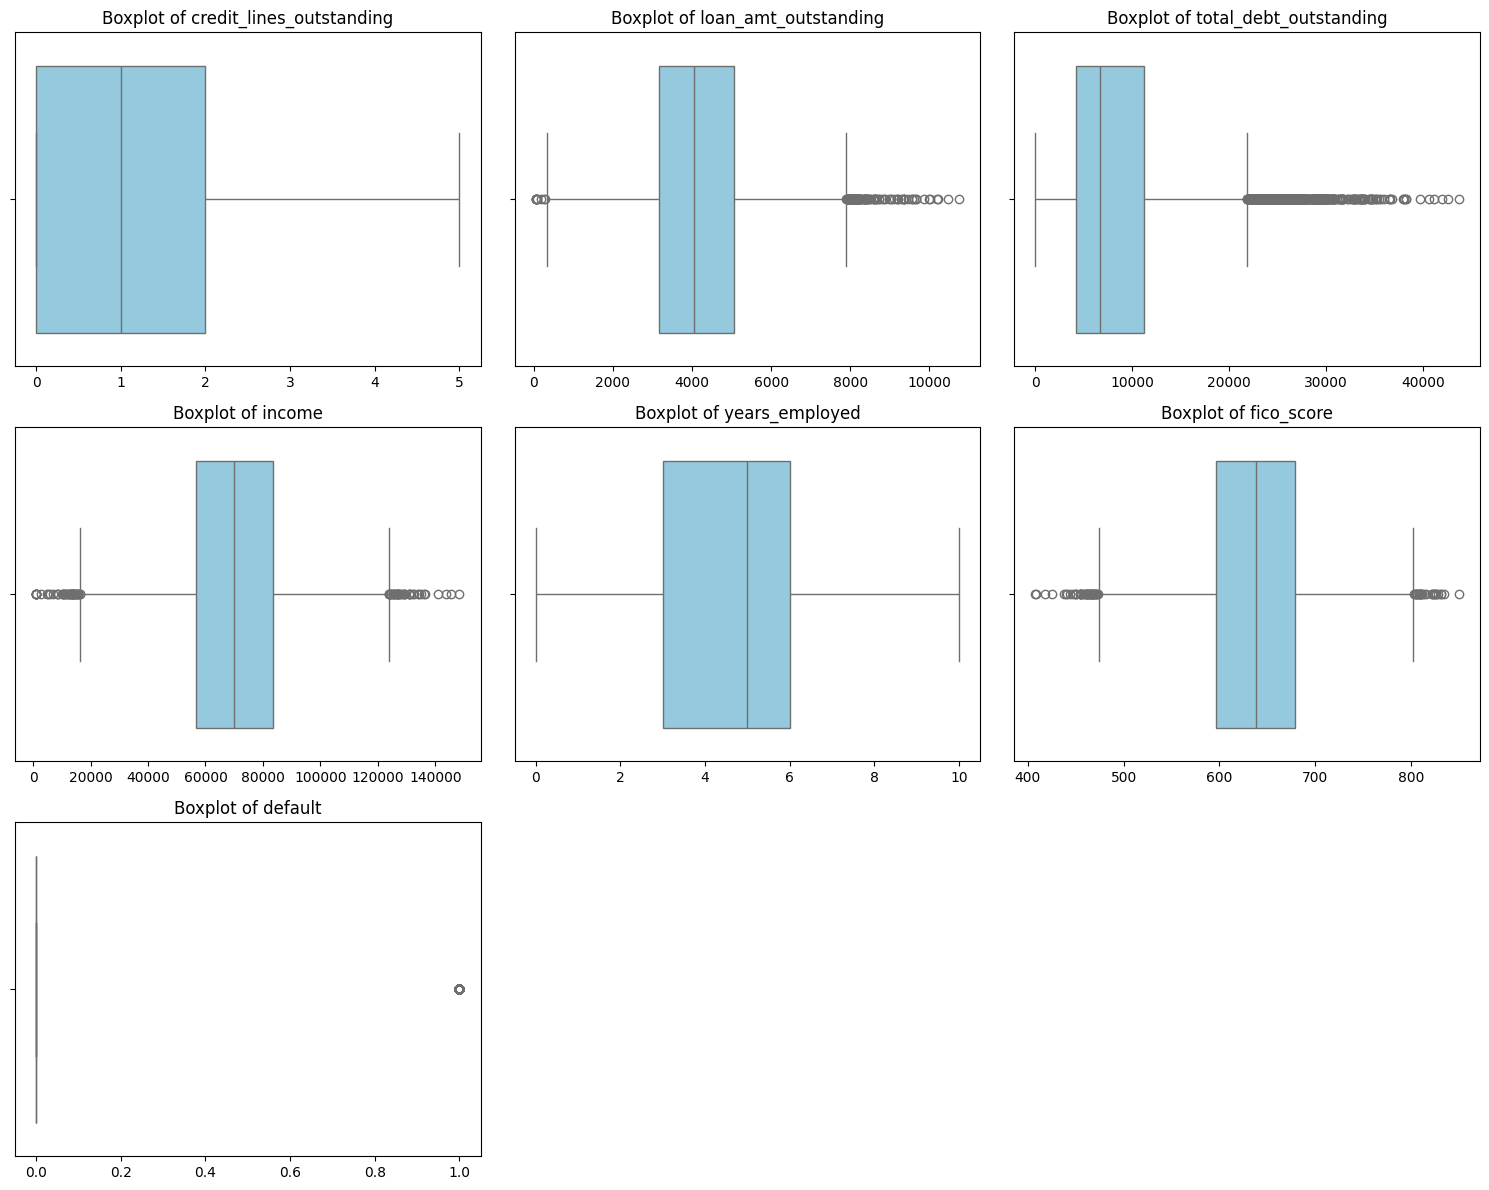

In [9]:
# Visualisation graphique de la répartition des données pour les colonnes pertinentes

# 1. Sélection des colonnes pertinentes
df_boxplt = df.drop(columns=['customer_id'])
numerical_features = df_boxplt.columns
n_features = len(numerical_features)

# 2. Configuration de la grille (ex: 3 colonnes)
n_cols = 3
n_rows = math.ceil(n_features / n_cols)

# 3. Création de la figure unique
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten() # On aplatit le tableau d'axes pour boucler facilement

for i, feature in enumerate(numerical_features):
    sns.boxplot(x=df[feature], ax=axes[i], color='skyblue')
    axes[i].set_title(f'Boxplot of {feature}')
    axes[i].set_xlabel('') # Optionnel : retire le label x pour plus de clarté

# 4. Supprimer les axes vides si le nombre de features n'est pas un multiple de n_cols
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

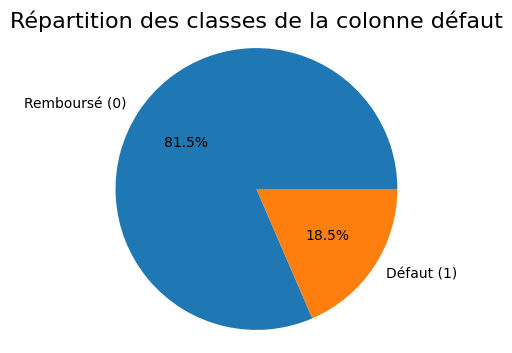

In [10]:
# Visualisation du déséquilibre de classe dans la colonne 'default'
class_counts = df['default'].value_counts()

# 2. Personnalisation du graphique
labels = ['Remboursé (0)', 'Défaut (1)']
sizes = class_counts.values

# 3. Création du Pie Chart
plt.figure(figsize=(4, 4)) 
plt.pie(sizes, labels=labels,
        autopct='%1.1f%%')

plt.title('Répartition des classes de la colonne défaut', fontsize=16)
plt.axis('equal')

# 4. Affichage
plt.show()

**ANALYSE :**

On observe un déséquilibre de classe, avec une minorité de clients qui font défaut (18,5%). Ce déséquilibre est à garder en tête lors de l'entraînement de nos modèles et l'interprétation des métriques de nos modèles de classification.

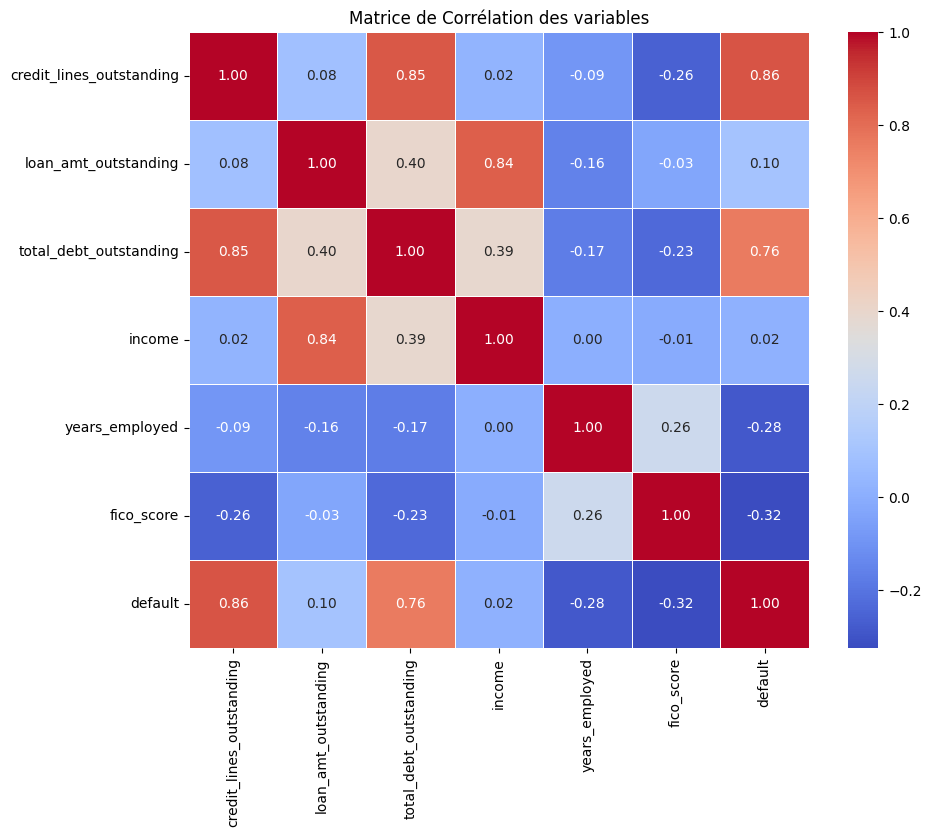

In [11]:
corr_matrix = df.drop(columns=['customer_id']).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matrice de Corrélation des variables")
plt.show()

In [12]:
df.groupby("default")["credit_lines_outstanding"].mean()

default
0    0.744140
1    4.618044
Name: credit_lines_outstanding, dtype: float64

**ANALYSE :**

D'après la matrice de corrélation, les deux principales variables corrélées au défaut d'un client seraient : 
- la 'credit_line_outstanding' (0.86) ;
- le 'total_debt_outstanding' (0,58). 

Ainsi, plus le client est globalement endetté, plus il aura tendance à faire défaut. 

On note cependant un *risque de fuite de données* avec le 'credit_line_outstanding'. En effet, s'il s'agit des données au moment du défaut du client, elles ne seront pas disponibles au moment de la contraction du prêt. De plus, la moyenne de cette valeur étant drastiquement plus élevée dans la classe 1 comparé à la classe 0, notre modèle risque d'utiliser cette feature comme raccourci pour réaliser sa prédiction. Pour ces raisons, nous décidons plus loin de l'exclure des variables exogènes.  

Le 'fico_score', qui semble tout indiqué pour étudier la propension d'un client à faire défaut, n'arrive néanmoins qu'en troisième place (-0,32). Il présente de même un score négatif, c'est-à-dire une corrélation négative, ce qui est logique : plus un fico-score plus élevé, plus proche de 800, plus le client est considéré fiable.  

Comme l'intuition le laisse deviner, l'ancienneté dans l'emploi actuel est une autre variable négativement corrélée au risque de défaut (-0.28). Plus on est stable dans son emploi, moins on risque de faire défaut. 

Le salaire ou le reste à payer sur le prêt étudié n'ont pas un impact fort sur la propension d'un client à faire défaut ; cependant le salaire est fortement corrélé à sa capacité d'emprunt et ce reste à payer est lui-même correlé avec le montant de la dette globale. 

Vues les subtilités révélées par la matrice de corrélation, il semble en effet pertinent de mettre en place un modèle de régression pour étudier le risque de défaut. 

## 1.2. Feature engineering et division train/test

On supprime des variables explicatives 'default' (notre colonne de prédiction), 'customer_id' (qui ne possède pas de lien avec le risque de défaut) et 'credit_line_outstanding' (contre le risque de fuite de données).

Nous voulons créer deux variables : *debt-to-income* à partir de "total_debt_outstanding" et *loan-to-income* à partir de "loan_atm_outstanding". 

In [13]:
X_raw = df.drop(columns=['default', 'customer_id', "credit_lines_outstanding"])
y = df['default']

In [14]:
# Vérification de la corrélation dans le df original avant feature engineering

vif_data = pd.DataFrame()
vif_data["feature"] = X_raw.columns
vif_data["VIF"] = [variance_inflation_factor(X_raw.values, i) 
                   for i in range(X_raw.shape[1])]
print(vif_data.sort_values("VIF", ascending=False))

                  feature        VIF
2                  income  47.415512
0    loan_amt_outstanding  35.007971
4              fico_score  21.446583
3          years_employed  11.125117
1  total_debt_outstanding   3.353495


In [15]:
def feature_engineering(X):
    X = X.copy()

    # Correction de l'asymétrie à droite avec un log
    X["dti"] = np.log(X["total_debt_outstanding"]) / X["income"]
    #X["lti"] = np.log(X["loan_amt_outstanding"]) / X["income"]
    return X[["income", "years_employed", "fico_score", "dti"]]

preprocessor = Pipeline([
    ("features", FunctionTransformer(feature_engineering))
])

X = preprocessor.fit_transform(X_raw)
print(X)

           income  years_employed  fico_score       dti
0     78039.38546               5         605  0.000106
1     26648.43525               2         572  0.000338
2     65866.71246               4         602  0.000116
3     74356.88347               5         612  0.000105
4     23448.32631               6         631  0.000319
...           ...             ...         ...       ...
9995  42691.62787               5         697  0.000184
9996  79969.50521               8         615  0.000108
9997  38192.67591               5         596  0.000222
9998  50929.37206               2         647  0.000136
9999  30611.62821               6         757  0.000262

[10000 rows x 4 columns]


In [16]:
# Vérification de la corrélation après feature engineering

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) 
                   for i in range(X.shape[1])]
print(vif_data.sort_values("VIF", ascending=False))

          feature        VIF
2      fico_score  26.770905
0          income  13.662061
1  years_employed  10.102586
3             dti   2.556726


In [17]:
# Ajout de stratify pour compenser the class imbalance

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [18]:
# Scaler pour regression logistique

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Définition et entraînement des modèles

## 2.1. Définition des modèles

In [43]:
#--- Logistic Regression

lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    C=0.001,  
    penalty='l2',
    solver='lbfgs'
)
lr.fit(X_train_scaled, y_train)

c:\Users\alize\Documents\SDA_2025_2026\projet_mlops\creditloanprediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.001
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [20]:
#--- Decision Tree

# 1. Définition des paramètres à tester
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5], # None = l'arbre pousse jusqu'au bout - overfitting
    'min_samples_split': [20, 50],
    'min_samples_leaf': [20, 50],
    'class_weight': ['balanced']
}

# 2. Configuration de la GridSearch
# On utilise cv=5 (Cross-Validation) pour être robuste
grid_search_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=5,
    scoring='roc_auc', # roc_auc pour dataset déséquilibré
    n_jobs=-1
)

# 3. Entraînement et évaluation
grid_search_dt.fit(X_train, y_train)
best_dt = grid_search_dt.best_estimator_

In [21]:
#--- Random Forest

# 1. Grille de paramètres pour la forêt
param_grid_rf = {
    'n_estimators': [100, 200],           # Nombre d'arbres dans la forêt
    'max_depth': [3, 5],          # Profondeur de chaque arbre
    'min_samples_leaf': [20, 50],        # Minimum d'échantillons par feuille
    'bootstrap': [True, False],
    'class_weight': ['balanced']            # Méthode de sélection des échantillons
}

# 2. Configuration GridSearch
grid_search_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

# 3. Entraînement et évaluation
grid_search_rf.fit(X_train, y_train)
best_rf = grid_search_rf.best_estimator_


Le XGBoost est un Random Forest qui va entraîner ses arbres les uns après les autres, et pas en parallèle, ce qui lui permet de les améliorer au fur et à mesure.

Contrairement au Gradient Boosting classique, l'Extreme Gradient Boosting possède aussi des paramètres de régularisation intégrés, ce qui évite le surapprentissage.

In [ ]:
# 1. Grille de paramètres pour XGBoost
# On teste la vitesse d'apprentissage, la profondeur et la proportion de données utilisées
param_grid_xgb_1 = {
    'n_estimators': [100, 200],           # Nombre d'arbres (itérations de boosting)
    'learning_rate': [0.01, 0.1, 0.2],    # Pas de progression (plus c'est bas, plus c'est robuste)
    'max_depth': [2, 3, 4],               # Profondeur des arbres (souvent plus faible que RF)
    'subsample': [0.8, 1.0],              # % de données utilisées par arbre (évite l'overfitting)
    #'colsample_bytree': [0.8, 1.0]        # % de colonnes utilisées par arbre
}

# 2. Configuration GridSearch
grid_search_xgb = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid_xgb_1,
    cv=5,
    scoring='f1',
    n_jobs=-1
    )

# 3. Entraînement 
grid_search_xgb.fit(X_train, y_train)

# 4. Résultats
print("Meilleurs paramètres XGBoost :", grid_search_xgb.best_params_)

# 5. Évaluation finale
best_xgb = grid_search_xgb.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)

print("\nReport du XGBoost Optimisé :")
print(classification_report(y_test, y_pred_xgb))

Meilleurs paramètres XGBoost : {'learning_rate': 0.2, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}

Report du XGBoost Optimisé :
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1630
           1       0.94      0.91      0.93       370

    accuracy                           0.97      2000
   macro avg       0.96      0.95      0.95      2000
weighted avg       0.97      0.97      0.97      2000



## 2.2. Entraînement des modèles

In [37]:
#--- Configuration MLFLOW avant entraînement

# On récupère le chemin absolu du dossier actuel
current_dir = os.getcwd()
db_path = os.path.join(current_dir, "mlflow.db")

# On force l'utilisation de ce fichier précis
mlflow.set_tracking_uri(f"sqlite:///{db_path}")
mlflow.set_experiment("credit-loan-prediction")

<Experiment: artifact_location='file:///c:/Users/alize/Documents/SDA_2025_2026/projet_mlops/creditloanprediction/mlruns/1', creation_time=1774797922153, experiment_id='1', last_update_time=1774797922153, lifecycle_stage='active', name='credit-loan-prediction', tags={}, workspace='default'>

In [38]:
# Engistrement de la pipeline de transformation de données dans mlflow

with mlflow.start_run(run_name="preprocessor"):
    mlflow.sklearn.log_model(
        preprocessor,
        name="preprocessor",
        registered_model_name="credit_loan_preprocessor"
    )
    print("Preprocessor enregistré.")

2026/04/06 19:09:14 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/06 19:09:14 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!


Preprocessor enregistré.


Registered model 'credit_loan_preprocessor' already exists. Creating a new version of this model...
Created version '6' of model 'credit_loan_preprocessor'.


In [45]:
#--- Entraînement des modèles et suivi dans MLFLOW

models = {
    "LogisticRegression": lr,
    "DecisionTree": best_dt,
    "RandomForest": best_rf,
    "XGB":best_xgb
}


for model_name, model in models.items():
    with mlflow.start_run(run_name=model_name):
        
        X_eval = X_test_scaled if model_name == "LogisticRegression" else X_test

        y_pred = model.predict(X_eval)
        probas = model.predict_proba(X_eval)[:, 1]
        report = classification_report(y_test, y_pred, output_dict=True)

        mlflow.log_metric("accuracy",        report["accuracy"])
        mlflow.log_metric("f1_class_1",      report["1"]["f1-score"])
        mlflow.log_metric("recall_class_1",  report["1"]["recall"])
        mlflow.log_metric("precision_class_1", report["1"]["precision"])
        mlflow.log_metric("roc_auc",         roc_auc_score(y_test, probas))

        model_info = mlflow.sklearn.log_model(
            model, 
            name=model_name,
            registered_model_name=model_name
        )

        # Staging
        client = mlflow.tracking.MlflowClient()
        latest_version = client.get_latest_versions(model_name, stages=["None"])[0].version
        client.transition_model_version_stage(
            name=model_name,
            version=latest_version,
            stage="Staging"
        )
        print(f"Modèle '{model_name}' v{latest_version} → Staging")


2026/04/06 19:25:26 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'LogisticRegression' already exists. Creating a new version of this model...
Created version '9' of model 'LogisticRegression'.
C:\Users\alize\AppData\Local\Temp\ipykernel_18680\1704832567.py:34: FutureWarning: ``mlflow.tracking.client.MlflowClient.get_latest_versions`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  latest_version = client.get_latest_versions(model_na

Modèle 'LogisticRegression' v9 → Staging


Registered model 'DecisionTree' already exists. Creating a new version of this model...
Created version '9' of model 'DecisionTree'.
C:\Users\alize\AppData\Local\Temp\ipykernel_18680\1704832567.py:34: FutureWarning: ``mlflow.tracking.client.MlflowClient.get_latest_versions`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  latest_version = client.get_latest_versions(model_name, stages=["None"])[0].version
C:\Users\alize\AppData\Local\Temp\ipykernel_18680\1704832567.py:35: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-regist

Modèle 'DecisionTree' v9 → Staging


2026/04/06 19:25:34 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'RandomForest' already exists. Creating a new version of this model...
Created version '9' of model 'RandomForest'.
C:\Users\alize\AppData\Local\Temp\ipykernel_18680\1704832567.py:34: FutureWarning: ``mlflow.tracking.client.MlflowClient.get_latest_versions`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  latest_version = client.get_latest_versions(model_name, stages=[

Modèle 'RandomForest' v9 → Staging
Modèle 'XGB' v7 → Staging


Registered model 'XGB' already exists. Creating a new version of this model...
Created version '7' of model 'XGB'.
C:\Users\alize\AppData\Local\Temp\ipykernel_18680\1704832567.py:34: FutureWarning: ``mlflow.tracking.client.MlflowClient.get_latest_versions`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  latest_version = client.get_latest_versions(model_name, stages=["None"])[0].version
C:\Users\alize\AppData\Local\Temp\ipykernel_18680\1704832567.py:35: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-

## 2.3. Enregistrement du meilleur modèle

In [47]:
# Trouver le meilleur run basé sur roc_auc
runs = mlflow.search_runs(
    experiment_names=["credit-loan-prediction"],
    order_by=["start_time DESC"]
)

# Garder les 4 derniers puis trier par roc_auc
best_run = runs.head(4).sort_values("metrics.roc_auc", ascending=False).iloc[0]

print(f"Meilleur modèle : {best_run['tags.mlflow.runName']}")
print(f"F1 score : {best_run['metrics.f1_class_1']:.4f}")
print(f"Accuracy : {best_run['metrics.accuracy']:.4f}")

# Enregistrer le meilleur modèle dans le Model Registry
best_run_id = best_run["run_id"]
model_name = best_run["tags.mlflow.runName"]

mlflow.register_model(
    model_uri=f"runs:/{best_run_id}/{model_name}",
    name="best_credit_loan_model"
)

# Laisser le temps au registry d'enregistrer
time.sleep(2)

client = mlflow.tracking.MlflowClient()

latest_version = client.get_latest_versions("best_credit_loan_model", stages=["None"])[0].version

# Passer en Production
client.transition_model_version_stage(
    name="best_credit_loan_model",
    version=latest_version,
    stage="Production"
)

print(f"Meilleur modèle '{model_name}' passé en production.")

Registered model 'best_credit_loan_model' already exists. Creating a new version of this model...
2026/04/06 19:26:08 WARNING mlflow.tracking._model_registry.fluent: Run with id b3dd0f439c7040b48f902878e0077a77 has no artifacts at artifact path 'XGB', registering model based on models:/m-61b9814452384517a217559a504a6193 instead


Meilleur modèle : XGB
F1 score : 0.9260
Accuracy : 0.9730


Created version '16' of model 'best_credit_loan_model'.


Meilleur modèle 'XGB' passé en production.


C:\Users\alize\AppData\Local\Temp\ipykernel_18680\3716400425.py:28: FutureWarning: ``mlflow.tracking.client.MlflowClient.get_latest_versions`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  latest_version = client.get_latest_versions("best_credit_loan_model", stages=["None"])[0].version
C:\Users\alize\AppData\Local\Temp\ipykernel_18680\3716400425.py:31: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  client.transition_model_version_stage(


## 2.4. Feature importance

In [40]:
# Récupérer les coefficients de la Régression Logistique (en valeur absolue pour comparer l'impact)
log_importances = pd.Series(abs(lr.coef_[0]), index=X.columns).sort_values(ascending=False)

# Récupérer l'importance des variables du Random Forest
rf_importances = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)

# Récupérer l'importance des variables du XGBoost_importances = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)
xgb_importances = pd.Series(best_xgb.feature_importances_, index=X.columns).sort_values(ascending=False)

print("\nTOP FEATURES - XGBoost:\n", xgb_importances, "\n")
print("TOP FEATURES - Random Forest:\n", rf_importances)
print("\nTOP FEATURES - LogReg:\n", log_importances)


TOP FEATURES - XGBoost:
 income            0.310204
years_employed    0.267404
dti               0.244986
fico_score        0.177407
dtype: float32 

TOP FEATURES - Random Forest:
 fico_score        0.332378
years_employed    0.241005
dti               0.229163
income            0.197453
dtype: float64

TOP FEATURES - LogReg:
 fico_score        0.724911
years_employed    0.625333
dti               0.606331
income            0.239758
dtype: float64


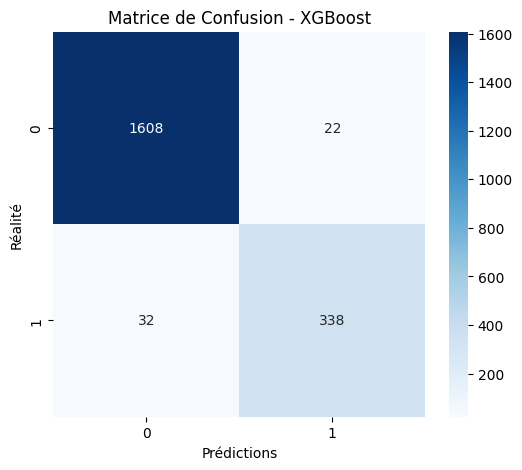

In [46]:
# matrice de confusion du XGBoost
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Prédictions')
plt.ylabel('Réalité')
plt.title('Matrice de Confusion - XGBoost')
plt.show()